In [16]:
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data

import numpy as np
import os
from datetime import datetime
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, average_precision_score, precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
import time
from sklearn.metrics import confusion_matrix, f1_score


In [17]:
# Get the dataset
dataset_final = pd.read_csv("../../data/processed/DatasetMaster.csv")
dataset_final.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='object')

In [18]:
# Split data function
X_train, X_test, y_train, y_test = split_data(dataset_final)

In [19]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


## Cross validation

In [20]:
# Define the 5-Fold Walk-Forward Split
tscv = TimeSeriesSplit(n_splits=5)

# Define the Pipeline: Scale the data dynamically, then apply Linear Math
# We use class_weight='balanced' to force the baseline to at least try to find the minority class
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

In [21]:
print("\n--- EXECUTING 5-FOLD WALK-FORWARD CROSS-VALIDATION ---")

fold_metrics = {'precision': [], 'recall': [], 'ap': []}

for fold, (train_index, val_index) in enumerate(tscv.split(X_train)):
    # 1. Isolate the Temporal Folds
    X_fold_train, X_fold_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_fold_train, y_fold_val = y_train.iloc[train_index], y_train.iloc[val_index]
    
    # 2. Train the Pipeline (Scaler fits ONLY on X_fold_train)
    pipeline.fit(X_fold_train, y_fold_train)
    
    # 3. Predict on the Validation Fold
    y_pred = pipeline.predict(X_fold_val)
    y_pred_proba = pipeline.predict_proba(X_fold_val)[:, 1]
    
    # 4. Calculate Hard Metrics
    prec = precision_score(y_fold_val, y_pred, zero_division=0)
    rec = recall_score(y_fold_val, y_pred, zero_division=0)
    ap = average_precision_score(y_fold_val, y_pred_proba)
    
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['ap'].append(ap)
    
    print(f"Fold {fold+1} | Precision: {prec:.3f} | Recall: {rec:.3f} | AP (PR-AUC): {ap:.3f}")


--- EXECUTING 5-FOLD WALK-FORWARD CROSS-VALIDATION ---
Fold 1 | Precision: 0.284 | Recall: 0.592 | AP (PR-AUC): 0.315
Fold 2 | Precision: 0.346 | Recall: 0.572 | AP (PR-AUC): 0.339
Fold 3 | Precision: 0.152 | Recall: 0.761 | AP (PR-AUC): 0.190
Fold 4 | Precision: 0.107 | Recall: 0.701 | AP (PR-AUC): 0.117
Fold 5 | Precision: 0.276 | Recall: 0.625 | AP (PR-AUC): 0.311


In [22]:
# ==========================================
# STEP 5: THE BASELINE VERDICT
# ==========================================
print("\n--- FINAL BASELINE CROSS-VALIDATION METRICS ---")
print(f"Average Precision : {np.mean(fold_metrics['precision']):.3f} (+/- {np.std(fold_metrics['precision']):.3f})")
print(f"Average Recall    : {np.mean(fold_metrics['recall']):.3f} (+/- {np.std(fold_metrics['recall']):.3f})")
print(f"Average PR-AUC    : {np.mean(fold_metrics['ap']):.3f} (+/- {np.std(fold_metrics['ap']):.3f})")
print("-----------------------------------------------")


--- FINAL BASELINE CROSS-VALIDATION METRICS ---
Average Precision : 0.233 (+/- 0.089)
Average Recall    : 0.650 (+/- 0.071)
Average PR-AUC    : 0.255 (+/- 0.086)
-----------------------------------------------


In [23]:
def save_run_metrics(
    model_name,
    run_id,
    y_true,
    y_proba,
    execution_time_minutes,
    threshold=0.40,
    csv_path="../results/logistic_regression_results.csv",
    extra_info=None
):

    # Create the results directory if it does not exist
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Convert probabilities into binary predictions using the selected threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Extract confusion matrix values for detailed evaluation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Store all evaluation metrics and experiment metadata in a dictionary
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model_name,
        "run_id": run_id,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "execution_time_minutes": execution_time_minutes
    }

    # Add optional extra experiment information if provided
    if extra_info is not None:
        row.update(extra_info)

    # Append results to the existing CSV file if it already exists
    if os.path.exists(csv_path):
        results_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [results_df, pd.DataFrame([row])],
            ignore_index=True
        )

    # Create a new dataframe if this is the first experiment run
    else:
        results_df = pd.DataFrame([row])

    # Save the updated results dataframe to disk
    results_df.to_csv(csv_path, index=False)

    # Return the stored metrics for immediate inspection
    return row

In [24]:
def train_logistic_regression(
    X_train,
    y_train,
    X_val,
    y_val,
    run_seed=42
):

    min_precision = 0.65

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=run_seed
        ))
    ])

    start = time.time()

    pipeline.fit(X_train, y_train)

    end = time.time()
    execution_minutes = (end - start) / 60

    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    best_threshold = 0.0
    best_precision = 0.0
    best_recall = 0.0
    best_f1 = 0.0

    for current_threshold in np.arange(0.10, 0.91, 0.05):
        y_val_pred = (y_val_proba >= current_threshold).astype(int)

        current_precision = precision_score(y_val, y_val_pred, zero_division=0)
        current_recall = recall_score(y_val, y_val_pred, zero_division=0)
        current_f1 = f1_score(y_val, y_val_pred, zero_division=0)

        if current_precision >= min_precision and current_recall > best_recall:
            best_precision = current_precision
            best_recall = current_recall
            best_f1 = current_f1
            best_threshold = current_threshold

    if best_threshold == 0.0:
        for current_threshold in np.arange(0.10, 0.91, 0.05):
            y_val_pred = (y_val_proba >= current_threshold).astype(int)

            current_precision = precision_score(y_val, y_val_pred, zero_division=0)
            current_recall = recall_score(y_val, y_val_pred, zero_division=0)
            current_f1 = f1_score(y_val, y_val_pred, zero_division=0)

            if current_f1 > best_f1:
                best_precision = current_precision
                best_recall = current_recall
                best_f1 = current_f1
                best_threshold = current_threshold

    tuning_results = {
        "best_threshold": best_threshold,
        "precision": best_precision,
        "recall": best_recall,
        "f1": best_f1
    }

    return pipeline, best_threshold, tuning_results, execution_minutes

## Full dataset

In [25]:
TOTAL_RUNS = 5

val_size = int(len(X_train) * 0.2)

X_train_final = X_train.iloc[:-val_size]
y_train_final = y_train.iloc[:-val_size]

X_val = X_train.iloc[-val_size:]
y_val = y_train.iloc[-val_size:]

for run in range(1, TOTAL_RUNS + 1):

    print("=" * 60)
    print(f"STARTING LOGISTIC REGRESSION RUN {run}/{TOTAL_RUNS}")
    print("=" * 60)

    logistic_model, winner_threshold, logistic_results, execution_minutes = train_logistic_regression(
        X_train=X_train_final,
        y_train=y_train_final,
        X_val=X_val,
        y_val=y_val,
        run_seed=42 + run
    )

    y_test_proba = logistic_model.predict_proba(X_test)[:, 1]

    save_run_metrics(
        model_name="LogisticRegression",
        run_id=run,
        y_true=y_test,
        y_proba=y_test_proba,
        execution_time_minutes=execution_minutes,
        threshold=winner_threshold,
        csv_path="../results/logistic_regression_results.csv"
    )

    print(f"RUN {run} COMPLETED")
    print(f"Winner threshold: {winner_threshold:.2f}")

final_logistic_model = logistic_model
final_winner_threshold = winner_threshold

STARTING LOGISTIC REGRESSION RUN 1/5
RUN 1 COMPLETED
Winner threshold: 0.45
STARTING LOGISTIC REGRESSION RUN 2/5
RUN 2 COMPLETED
Winner threshold: 0.45
STARTING LOGISTIC REGRESSION RUN 3/5
RUN 3 COMPLETED
Winner threshold: 0.45
STARTING LOGISTIC REGRESSION RUN 4/5
RUN 4 COMPLETED
Winner threshold: 0.45
STARTING LOGISTIC REGRESSION RUN 5/5
RUN 5 COMPLETED
Winner threshold: 0.45


Evaluating on unseen 2025 future state...

--- OFFICIAL 2025 CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.81      0.78      0.79    105203
           1       0.63      0.68      0.65     58954

    accuracy                           0.74    164157
   macro avg       0.72      0.73      0.72    164157
weighted avg       0.75      0.74      0.74    164157


Final Average Precision (PR-AUC): 0.697


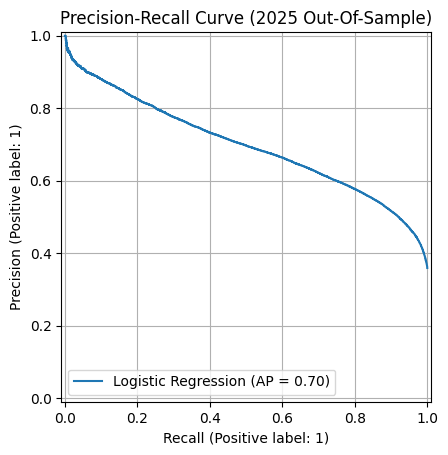

In [26]:
print("Evaluating on unseen 2025 future state...")
y_test_proba = final_logistic_model.predict_proba(X_test)[:, 1]
y_pred = (y_test_proba >= final_winner_threshold).astype(int)

# ==========================================
# STEP 6: METRICS & VISUALIZATION
# ==========================================
print("\n--- OFFICIAL 2025 CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

ap = average_precision_score(y_test, y_test_proba)
print(f"\nFinal Average Precision (PR-AUC): {ap:.3f}")

# Generate the PR Curve
disp = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="Logistic Regression"
)
plt.title("Precision-Recall Curve (2025 Out-Of-Sample)")
plt.grid(True)
plt.show()